Original opened: True
Stego opened: True
Original frames: 242
Stego frames: 242
Processed frames: 242


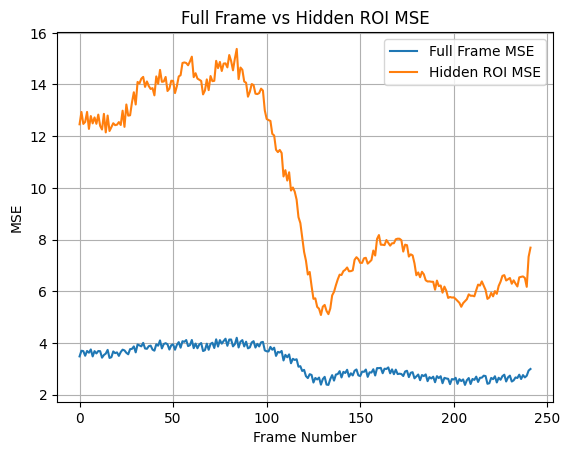

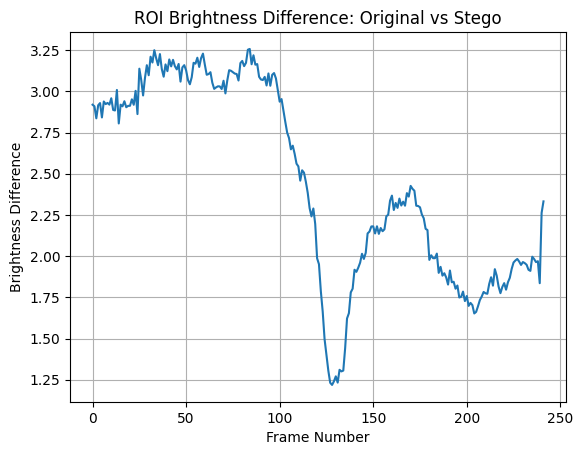

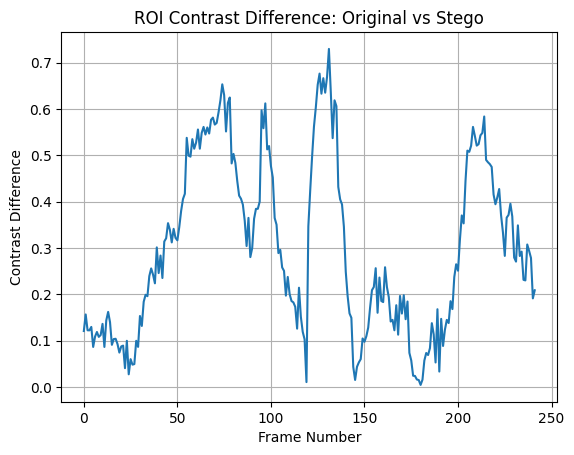

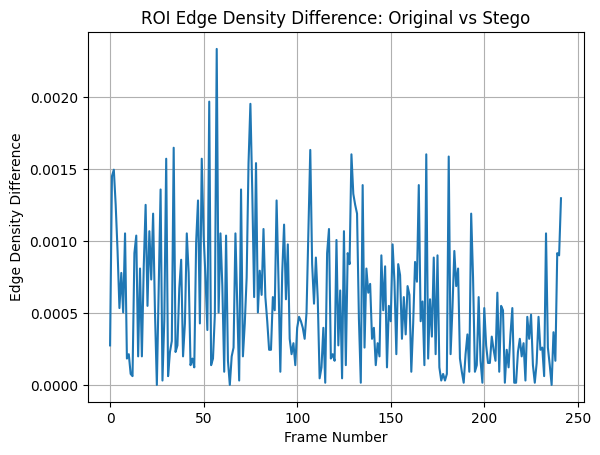

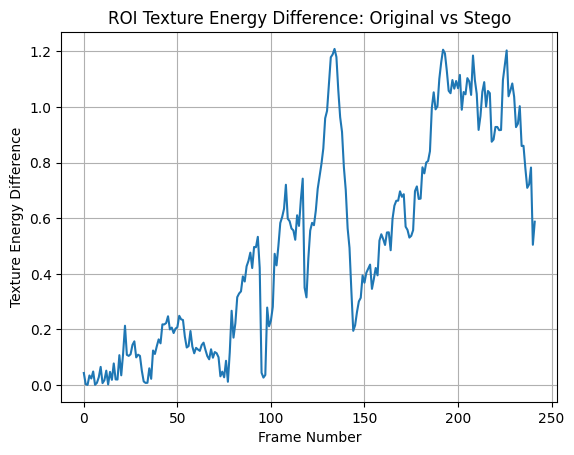

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

original_path = r"C:\Users\yasse\Downloads\drive-download-20260425T162603Z-3-001\Original video.mp4"
stego_path = r"C:\Users\yasse\Downloads\drive-download-20260425T162603Z-3-001\final_patched_widescreen.mp4"

original_cap = cv2.VideoCapture(original_path)
stego_cap = cv2.VideoCapture(stego_path)

print("Original opened:", original_cap.isOpened())
print("Stego opened:", stego_cap.isOpened())
print("Original frames:", int(original_cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("Stego frames:", int(stego_cap.get(cv2.CAP_PROP_FRAME_COUNT)))

if not original_cap.isOpened():
    raise Exception("Original video did not open. Check path/name.")

if not stego_cap.isOpened():
    raise Exception("Stego video did not open. Check path/name.")

frame_numbers = []

roi_mse_values = []
full_mse_values = []

roi_brightness_diff = []
roi_contrast_diff = []
roi_edge_diff = []
roi_texture_diff = []

# Expected video dimensions and hidden ROI
video_width = 848
video_height = 478
patch_size = 256

x_start = 0
x_end = patch_size
y_start = video_height - patch_size
y_end = video_height

frame_index = 0

while True:
    ret1, original_frame = original_cap.read()
    ret2, stego_frame = stego_cap.read()

    if not ret1 or not ret2:
        break

    original_frame = cv2.resize(original_frame, (video_width, video_height))
    stego_frame = cv2.resize(stego_frame, (video_width, video_height))

    original_gray = cv2.cvtColor(original_frame, cv2.COLOR_BGR2GRAY)
    stego_gray = cv2.cvtColor(stego_frame, cv2.COLOR_BGR2GRAY)

    original_roi = original_gray[y_start:y_end, x_start:x_end]
    stego_roi = stego_gray[y_start:y_end, x_start:x_end]

    # Full-frame MSE
    full_mse = np.mean((original_gray.astype(float) - stego_gray.astype(float)) ** 2)

    # ROI MSE
    roi_mse = np.mean((original_roi.astype(float) - stego_roi.astype(float)) ** 2)

    # Brightness difference inside hidden ROI
    brightness_diff = abs(np.mean(original_roi) - np.mean(stego_roi))

    # Contrast difference inside hidden ROI
    contrast_diff = abs(np.std(original_roi) - np.std(stego_roi))

    # Edge density difference inside hidden ROI
    original_edges = cv2.Canny(original_roi, 100, 200)
    stego_edges = cv2.Canny(stego_roi, 100, 200)

    original_edge_density = np.sum(original_edges > 0) / original_edges.size
    stego_edge_density = np.sum(stego_edges > 0) / stego_edges.size
    edge_diff = abs(original_edge_density - stego_edge_density)

    # Texture energy difference inside hidden ROI
    original_grad_x = cv2.Sobel(original_roi, cv2.CV_64F, 1, 0, ksize=3)
    original_grad_y = cv2.Sobel(original_roi, cv2.CV_64F, 0, 1, ksize=3)
    stego_grad_x = cv2.Sobel(stego_roi, cv2.CV_64F, 1, 0, ksize=3)
    stego_grad_y = cv2.Sobel(stego_roi, cv2.CV_64F, 0, 1, ksize=3)

    original_texture = np.mean(np.sqrt(original_grad_x**2 + original_grad_y**2))
    stego_texture = np.mean(np.sqrt(stego_grad_x**2 + stego_grad_y**2))
    texture_diff = abs(original_texture - stego_texture)

    frame_numbers.append(frame_index)
    full_mse_values.append(full_mse)
    roi_mse_values.append(roi_mse)
    roi_brightness_diff.append(brightness_diff)
    roi_contrast_diff.append(contrast_diff)
    roi_edge_diff.append(edge_diff)
    roi_texture_diff.append(texture_diff)

    frame_index += 1

original_cap.release()
stego_cap.release()

print("Processed frames:", len(frame_numbers))

plt.figure()
plt.plot(frame_numbers, full_mse_values, label="Full Frame MSE")
plt.plot(frame_numbers, roi_mse_values, label="Hidden ROI MSE")
plt.title("Full Frame vs Hidden ROI MSE")
plt.xlabel("Frame Number")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, roi_brightness_diff)
plt.title("ROI Brightness Difference: Original vs Stego")
plt.xlabel("Frame Number")
plt.ylabel("Brightness Difference")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, roi_contrast_diff)
plt.title("ROI Contrast Difference: Original vs Stego")
plt.xlabel("Frame Number")
plt.ylabel("Contrast Difference")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, roi_edge_diff)
plt.title("ROI Edge Density Difference: Original vs Stego")
plt.xlabel("Frame Number")
plt.ylabel("Edge Density Difference")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, roi_texture_diff)
plt.title("ROI Texture Energy Difference: Original vs Stego")
plt.xlabel("Frame Number")
plt.ylabel("Texture Energy Difference")
plt.grid(True)
plt.show()